
# Tier 1 — National Screening: CCS Potential Across Indonesian Basins

**Status: PROTOTYPE.** This notebook automatically uses **real emitter
data** (`data/processed/basins_processed.csv`, `data/raw/indonesia_emitters_real.csv`)
if present, and falls back to **illustrative sample data** otherwise — the
active data source is always printed explicitly in Section 1.

This notebook replicates the *spirit* of two studies:

- **de Jonge-Anderson et al. (2025)** — *Malay Basin*, IJGGC 143 — technical
  workflow (subsurface cut-offs, CO2 thermophysics, clustering, Monte Carlo).
- **Nooraiepour et al. (2025)** — *Poland*, IJGGC 148 — strategic framework
  for an emerging CCS region: **resource-reserve pyramid** & **Storage
  Readiness Level (SRL)**.

> ⚠️ Capacity figures and basin geometry are **illustrative** unless the
> active-data-source message in Section 1 says otherwise. See
> `docs/methodology.md` for full limitations.


## 0. Setup

In [1]:

import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_p = Path.cwd()
while not (_p / "config.yaml").exists() and _p != _p.parent:
    _p = _p.parent
REPO_ROOT = _p
sys.path.insert(0, str(REPO_ROOT / "src"))

from load_config import load_config
from emission_source_proximity import nearest_emitter_distance, basin_accessibility_scores
from montecarlo_capacity import monte_carlo_capacity, summarize_capacity, NormalParam

cfg = load_config(REPO_ROOT / "config.yaml")
pd.set_option("display.max_colwidth", 60)
print("Repo root:", REPO_ROOT)
print("Target SRL Tier 1:", cfg["storage_readiness"]["tier1_target_srl"])


Repo root: C:\Users\Arsy Nuur\ccs-screening
Target SRL Tier 1: 1


## 1. Load basin & emission source data

Priority: real data (`config.yaml` §`paths.real`) first, illustrative
sample data (`config.yaml` §`paths.sample`) as fallback — generated
automatically via `fetch_open_data.py` if not already present.


In [2]:

real_basins_path = REPO_ROOT / cfg["paths"]["real"]["basins_processed"]
real_emitters_path = REPO_ROOT / cfg["paths"]["real"]["emitters"]
sample_basins_path = REPO_ROOT / cfg["paths"]["sample"]["basins"]
sample_emitters_path = REPO_ROOT / cfg["paths"]["sample"]["emitters"]

# Make sure the illustrative fallback files exist (safe to call repeatedly)
if not sample_basins_path.exists() or not sample_emitters_path.exists():
    subprocess.run([sys.executable, str(REPO_ROOT / "src" / "fetch_open_data.py"), "--mode", "sample"], check=True)

print("=== ACTIVE DATA SOURCE ===")
if real_basins_path.exists():
    basins_path, basins_source = real_basins_path, "REAL"
else:
    basins_path, basins_source = sample_basins_path, "ILLUSTRATIVE (sample)"
print(f"Basins  : {basins_source} -> {basins_path.name}")

if real_emitters_path.exists():
    emitters_path, emitters_source = real_emitters_path, "REAL"
else:
    emitters_path, emitters_source = sample_emitters_path, "ILLUSTRATIVE (sample)"
print(f"Emitters: {emitters_source} -> {emitters_path.name}")
print("==========================\n")

basins = pd.read_csv(basins_path)
emitters = pd.read_csv(emitters_path)

# Align column names in case real data uses different conventions
# (e.g. GEM-style "Latitude"/"Longitude" instead of "lat"/"lon").
emitters = emitters.rename(columns={
    "Latitude": "lat", "Longitude": "lon", "annual_co2_mtpa": "capacity_mtpa_co2_est",
})
if "name" not in emitters.columns:
    emitters["name"] = emitters.get("Plant name", "unnamed_emitter")
if "sector" not in emitters.columns:
    emitters["sector"] = "unknown"

print(f"{len(basins)} basins, {len(emitters)} emitter points loaded.")
basins[["basin", "region", "basin_type", "ccs_policy_priority", "srl_placeholder"]]


=== ACTIVE DATA SOURCE ===
Basins  : ILLUSTRATIVE (sample) -> sample_basins_indonesia.csv
Emitters: REAL -> indonesia_emitters_real.csv

8 basins, 526 emitter points loaded.


,basin,region,basin_type,ccs_policy_priority,srl_placeholder
0,Sunda-Asri Basin,Offshore West Java,"Rift, saline aquifer + depleted field",True,1
1,South Sumatra Basin,Onshore/nearshore South Sumatra,"Foreland/back-arc, depleted field",True,1
2,North Sumatra Basin,Onshore/offshore Aceh-North Sumatra,"Rift/foreland, depleted field",False,1
3,Northwest Java Basin,Onshore/offshore West Java,"Rift, saline aquifer",False,1
4,East Java Basin,Onshore/offshore East Java,"Foreland, depleted field",False,1
5,Kutai Basin,Offshore East Kalimantan,"Deltaic rift, saline aquifer",False,1
6,Bintuni Basin,Onshore/offshore West Papua,"Foreland, depleted field",True,1
7,"Malay Basin (Natuna, Indonesian side)",Offshore Riau Islands,"Rift, saline aquifer + depleted field",False,1


## 2. Storage Readiness Level (SRL) framework per basin

| SRL | Description |
|---|---|
| 1 | First-pass, basin/country-scale assessment using existing geological data |
| 2 | Sites with theoretical capacity mapped systematically |
| 3 | Detailed site-specific screening study + preliminary project concept |

All example basins here stay at **SRL 1** — honest, given this only uses
basin-level public data, not well data.


In [3]:

srl_labels = {1: "SRL 1 - basin-scale, public data", 2: "SRL 2 - systematically mapped capacity", 3: "SRL 3 - site-specific detailed screening"}
basins["srl_label"] = basins["srl_placeholder"].map(srl_labels)
basins[["basin", "srl_placeholder", "srl_label", "ccs_policy_priority"]]


,basin,srl_placeholder,srl_label,ccs_policy_priority
0,Sunda-Asri Basin,1,"SRL 1 - basin-scale, public data",True
1,South Sumatra Basin,1,"SRL 1 - basin-scale, public data",True
2,North Sumatra Basin,1,"SRL 1 - basin-scale, public data",False
3,Northwest Java Basin,1,"SRL 1 - basin-scale, public data",False
4,East Java Basin,1,"SRL 1 - basin-scale, public data",False
5,Kutai Basin,1,"SRL 1 - basin-scale, public data",False
6,Bintuni Basin,1,"SRL 1 - basin-scale, public data",True
7,"Malay Basin (Natuna, Indonesian side)",1,"SRL 1 - basin-scale, public data",False


## 3. Proximity to CO2 emission sources

Great-circle distance from each basin centroid to the nearest emitter
(analogous to Fig. 7 in the Poland paper).


In [4]:

capacity_col = "capacity_mtpa_co2_est" if "capacity_mtpa_co2_est" in emitters.columns else None

basins_with_proximity = nearest_emitter_distance(
    basins, emitters,
    basin_lat_col="lat", basin_lon_col="lon",
    emitter_lat_col="lat", emitter_lon_col="lon",
    emitter_capacity_col=capacity_col,
)
cols = ["basin", "nearest_emitter_name", "nearest_emitter_km"]
if "nearest_emitter_capacity" in basins_with_proximity.columns:
    cols.append("nearest_emitter_capacity")
basins_with_proximity[cols].sort_values("nearest_emitter_km")


,basin,nearest_emitter_name,nearest_emitter_km,nearest_emitter_capacity
4,East Java Basin,Gresik AKR power station,23.624363,0.000000
3,Northwest Java Basin,Indramayu power station,31.526236,1.958919
1,South Sumatra Basin,Shenhua Guohua power station,43.808889,1.013804
0,Sunda-Asri Basin,Jabar Utara power station,47.740675,0.000000
5,Kutai Basin,Kaltim-4 power station,50.531624,0.593612
2,North Sumatra Basin,Tanjung Pasir power station,89.678936,0.000000
6,Bintuni Basin,Sorong power station,295.529457,0.000000
7,"Malay Basin (Natuna, Indonesian side)",Kalselteng-4 Hybrid power station,351.013311,0.586995


### 3b. Catchment / accessibility analysis (within 200 km)

`nearest_emitter_km` above only tells you about the single closest emitter —
it misses the bigger picture of *how much total emission capacity* a basin
can realistically serve as a hub. This section adds a gravity-style
**accessibility index** (a well-established spatial analysis concept):

$$\text{accessibility} = \sum_{i \in \text{radius}} \frac{\text{capacity}_i}{\max(\text{distance}_i,\ \text{floor})}$$

Basins surrounded by many emitters score higher than basins merely close to
one large plant. Radius = **200 km** — "loose, realistic for a regional
hub" (per project decision), configurable in `config.yaml` §`tier1_scoring`.


In [5]:

ts = cfg["tier1_scoring"]

basins_scored = basin_accessibility_scores(
    basins, emitters,
    radius_km=ts["search_radius_km"],
    min_distance_floor_km=ts["min_distance_floor_km"],
    basin_lat_col="lat", basin_lon_col="lon",
    emitter_lat_col="lat", emitter_lon_col="lon",
    capacity_col="capacity_mtpa_co2_est" if "capacity_mtpa_co2_est" in emitters.columns else "lat",  # fallback avoids KeyError; falls back to count-only weighting
)
basins_scored[["basin", "n_emitters_within_radius", "total_capacity_within_radius_mtpa", "accessibility_index"]] \
    .sort_values("accessibility_index", ascending=False)


,basin,n_emitters_within_radius,total_capacity_within_radius_mtpa,accessibility_index
0,Sunda-Asri Basin,59,94.291577,0.679141
3,Northwest Java Basin,39,50.277070,0.511814
4,East Java Basin,24,41.545001,0.350451
1,South Sumatra Basin,40,20.576077,0.252187
2,North Sumatra Basin,14,11.427028,0.092744
5,Kutai Basin,21,4.066241,0.062359
6,Bintuni Basin,0,0.000000,0.000000
7,"Malay Basin (Natuna, Indonesian side)",0,0.000000,0.000000


## 4. Resource-reserve pyramid per basin (Monte Carlo)

Distribution parameters (Swirr, efficiency factor) come from `config.yaml`;
area/thickness/NTG/porosity/density use illustrative ranges per basin
(labelled explicitly — see `docs/methodology.md`).


In [6]:

ce = cfg["capacity_equation"]
rng = np.random.default_rng(42)
illustrative_results = []

for _, row in basins.iterrows():
    area_km2 = rng.uniform(5_000, 70_000)  # order-of-magnitude realistic for a sedimentary basin
    mc = monte_carlo_capacity(
        area_km2=area_km2,
        thickness_m=NormalParam(mean=rng.uniform(150, 500), std=100, lower_bound=0),
        ntg_fraction=NormalParam(mean=rng.uniform(0.15, 0.4), std=0.1, lower_bound=0, upper_bound=1),
        porosity_fraction=NormalParam(mean=rng.uniform(0.15, 0.28), std=0.04, lower_bound=0, upper_bound=1),
        swirr_fraction=NormalParam(mean=ce["swirr_mean"], std=ce["swirr_std"], lower_bound=0, upper_bound=1),
        efficiency_fraction=NormalParam(
            mean=ce["efficiency_factor_percent_mean"] / 100,
            std=ce["efficiency_factor_percent_std"] / 100,
            lower_bound=0, upper_bound=1,
        ),
        co2_density_kgm3=NormalParam(mean=rng.uniform(300, 450), std=40, lower_bound=0),
        n_iterations=ce["monte_carlo_iterations"],
        random_seed=int(rng.integers(0, 10_000)),
    )
    stats = summarize_capacity(mc)
    stats["basin"] = row["basin"]
    stats["illustrative_area_km2"] = area_km2
    illustrative_results.append(stats)

illustrative_df = pd.DataFrame(illustrative_results).set_index("basin")
illustrative_df = illustrative_df[["illustrative_area_km2", "P10_Gt", "P50_Gt", "P90_Gt", "mean_Gt", "std_Gt"]]
illustrative_df.round(2)


,illustrative_area_km2,P10_Gt,P50_Gt,P90_Gt,mean_Gt,std_Gt
basin,,,,,,
Sunda-Asri Basin,55307.14,11.02,5.70,2.31,6.39,3.69
South Sumatra Basin,54474.08,8.56,3.68,0.83,4.37,3.30
North Sumatra Basin,65239.72,15.01,8.08,3.85,8.99,4.67
Northwest Java Basin,9148.12,2.67,1.40,0.62,1.54,0.84
East Java Basin,68095.37,16.73,9.10,4.26,9.92,5.22
Kutai Basin,15028.82,4.87,2.56,1.15,2.79,1.47
Bintuni Basin,29079.88,3.00,1.33,0.41,1.55,1.09
"Malay Basin (Natuna, Indonesian side)",48537.91,10.50,5.69,2.69,6.32,3.49


### 4b. Dual ranking: storage-first vs. cost-first

Rather than forcing one blended weight between storage and cost (a
subjective choice this project isn't in a position to make on your behalf),
this shows **both rankings side by side**. A basin that ranks highly in
*both* is a much more robust pick than one that only wins under a single
weighting scheme.


In [7]:

ranking_df = illustrative_df.merge(
    basins_scored.set_index("basin")[["lat", "lon", "accessibility_index", "total_capacity_within_radius_mtpa", "n_emitters_within_radius"]],
    left_index=True, right_index=True,
)

# Normalize both scores to 0-1 so they're comparable
ranking_df["storage_score"] = (ranking_df["P50_Gt"] - ranking_df["P50_Gt"].min()) / (ranking_df["P50_Gt"].max() - ranking_df["P50_Gt"].min())
ranking_df["cost_score"] = (ranking_df["accessibility_index"] - ranking_df["accessibility_index"].min()) / (ranking_df["accessibility_index"].max() - ranking_df["accessibility_index"].min())

storage_first = ranking_df.sort_values("storage_score", ascending=False)
cost_first = ranking_df.sort_values("cost_score", ascending=False)

top3_storage = set(storage_first.head(3).index)
top3_cost = set(cost_first.head(3).index)
robust_picks = top3_storage & top3_cost

print("=== Ranking A: STORAGE-FIRST (by illustrative P50 capacity) ===")
print(storage_first[["P50_Gt", "storage_score", "cost_score"]].round(3).to_string())
print("\n=== Ranking B: COST-FIRST (by accessibility index) ===")
print(cost_first[["accessibility_index", "cost_score", "storage_score"]].round(3).to_string())

print(f"\n{'='*65}")
if robust_picks:
    print(f"ROBUST PICK(S) — appear in TOP 3 of BOTH rankings: {sorted(robust_picks)}")
else:
    print("No basin appears in the top 3 of both rankings — storage and cost")
    print("point to different basins here; this is a genuine trade-off to")
    print("discuss, not something this notebook should silently resolve for you.")
print(f"{'='*65}")


=== Ranking A: STORAGE-FIRST (by illustrative P50 capacity) ===
                                       P50_Gt  storage_score  cost_score
basin                                                                   
East Java Basin                         9.095          1.000       0.516
North Sumatra Basin                     8.083          0.870       0.137
Sunda-Asri Basin                        5.699          0.563       1.000
Malay Basin (Natuna, Indonesian side)   5.685          0.561       0.000
South Sumatra Basin                     3.683          0.303       0.371
Kutai Basin                             2.556          0.158       0.092
Northwest Java Basin                    1.397          0.009       0.754
Bintuni Basin                           1.326          0.000       0.000

=== Ranking B: COST-FIRST (by accessibility index) ===
                                       accessibility_index  cost_score  storage_score
basin                                                           

## 5. Summary visualization (style of Table 2 / Fig. 7, Poland paper)

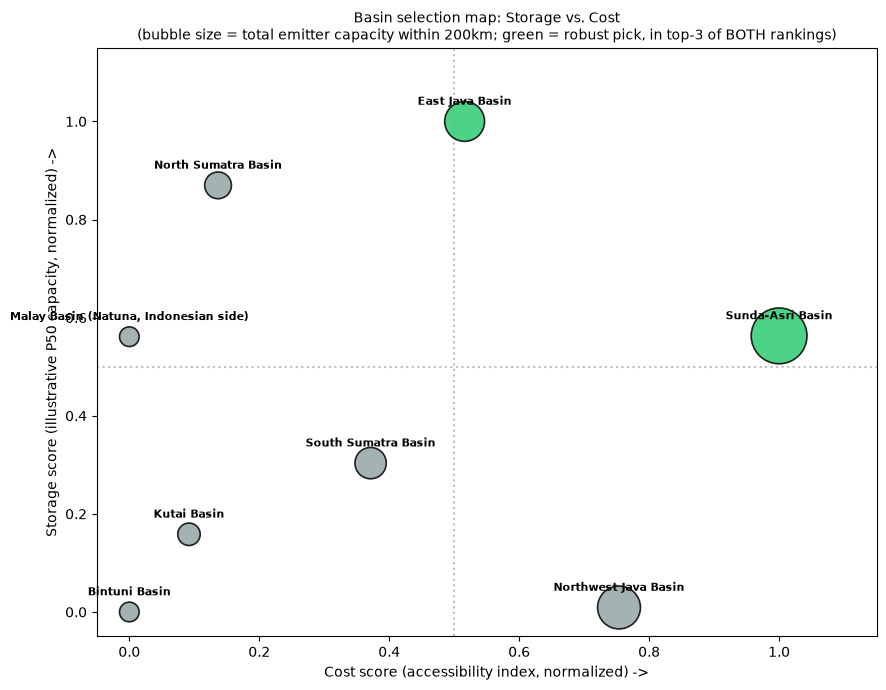

In [8]:

fig, ax = plt.subplots(figsize=(9, 7))

colors = ["#2ecc71" if b in robust_picks else "#95a5a6" for b in ranking_df.index]
sizes = 200 + 15 * ranking_df["total_capacity_within_radius_mtpa"]

scatter = ax.scatter(
    ranking_df["cost_score"], ranking_df["storage_score"],
    s=sizes, c=colors, edgecolor="black", linewidth=1.2, alpha=0.85, zorder=3,
)

for basin_name, row in ranking_df.iterrows():
    ax.annotate(
        basin_name, (row["cost_score"], row["storage_score"]),
        textcoords="offset points", xytext=(0, 12), ha="center", fontsize=8, weight="bold",
    )

ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Cost score (accessibility index, normalized) ->", fontsize=10)
ax.set_ylabel("Storage score (illustrative P50 capacity, normalized) ->", fontsize=10)
ax.set_title(
    "Basin selection map: Storage vs. Cost\n"
    "(bubble size = total emitter capacity within 200km; green = robust pick, in top-3 of BOTH rankings)",
    fontsize=10,
)
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()

figures_dir = REPO_ROOT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "tier1_storage_vs_cost_bubble.png", dpi=150)
plt.show()


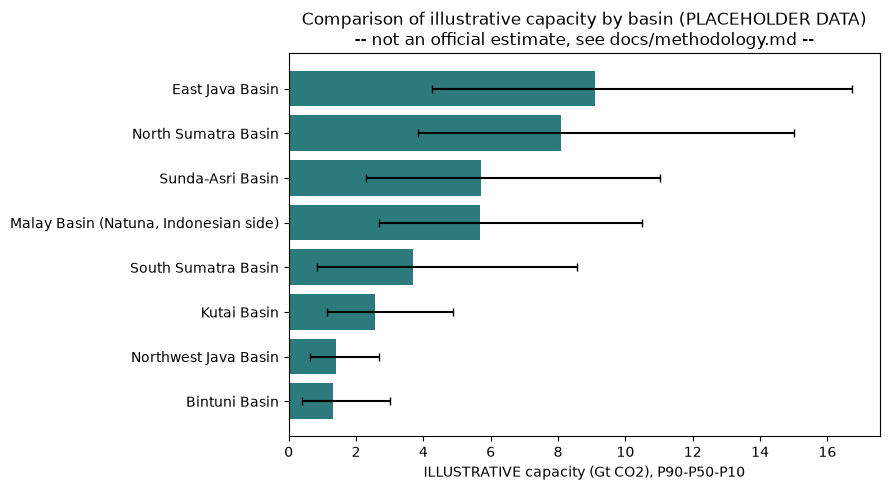

In [9]:

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = illustrative_df.sort_values("P50_Gt", ascending=True)
ax.barh(plot_df.index, plot_df["P50_Gt"], color="#2c7a7b")
ax.errorbar(
    plot_df["P50_Gt"], plot_df.index,
    xerr=[plot_df["P50_Gt"] - plot_df["P90_Gt"], plot_df["P10_Gt"] - plot_df["P50_Gt"]],
    fmt="none", ecolor="black", capsize=3,
)
ax.set_xlabel("ILLUSTRATIVE capacity (Gt CO2), P90-P50-P10")
ax.set_title("Comparison of illustrative capacity by basin (PLACEHOLDER DATA)\n"
              "-- not an official estimate, see docs/methodology.md --")
plt.tight_layout()

figures_dir = REPO_ROOT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "tier1_illustrative_capacity_comparison.png", dpi=150)
plt.show()


In [10]:

import folium
from folium.plugins import HeatMap

m = folium.Map(location=[-2.5, 113], zoom_start=5, tiles="cartodbpositron")

# --- Layer 1: emitter density heatmap (weighted by capacity) ---
heat_data = [
    [row["lat"], row["lon"], row.get("capacity_mtpa_co2_est", 1.0) if pd.notna(row.get("capacity_mtpa_co2_est", 1.0)) else 1.0]
    for _, row in emitters.iterrows()
]
HeatMap(heat_data, name="Emitter density (weighted by capacity)", radius=22, blur=18, max_zoom=6).add_to(
    folium.FeatureGroup(name="Emitter heatmap").add_to(m)
)

# --- Layer 2: 200km catchment radius ring per basin (visualizes cost/reach) ---
radius_layer = folium.FeatureGroup(name=f"{ts['search_radius_km']} km catchment radius")
for _, row in basins_scored.iterrows():
    folium.Circle(
        location=[row["lat"], row["lon"]], radius=ts["search_radius_km"] * 1000,
        color="#f39c12", weight=1, fill=True, fill_opacity=0.04, dash_array="4",
    ).add_to(radius_layer)
radius_layer.add_to(m)

# --- Layer 3: basin markers, colored by robust-pick status, sized by storage score ---
basin_layer = folium.FeatureGroup(name="Basins (color = robust pick, size = storage score)")
for basin_name, row in ranking_df.iterrows():
    is_robust = basin_name in robust_picks
    color = "#2ecc71" if is_robust else ("#e67e22" if row["storage_score"] >= 0.5 or row["cost_score"] >= 0.5 else "#95a5a6")
    radius_px = 10 + 12 * row["storage_score"]
    popup_html = (
        f"<b>{basin_name}</b><br>"
        f"Storage score: {row['storage_score']:.2f} (P50 {row['P50_Gt']:.2f} Gt)<br>"
        f"Cost score: {row['cost_score']:.2f} (accessibility idx {row['accessibility_index']:.1f})<br>"
        f"Emitters within {ts['search_radius_km']}km: {int(row['n_emitters_within_radius'])} "
        f"({row['total_capacity_within_radius_mtpa']:.1f} Mt CO2/yr total)<br>"
        f"{'<b>ROBUST PICK</b> (top-3 in both rankings)' if is_robust else ''}"
    )
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=radius_px, color=color, fill=True, fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=280),
    ).add_to(basin_layer)
    folium.map.Marker(
        [row["lat"], row["lon"]],
        icon=folium.DivIcon(html=f'<div style="font-size:10px; font-weight:bold; color:#2c3e50; '
                                  f'text-shadow:1px 1px 2px white;">{basin_name}</div>'),
    ).add_to(basin_layer)
basin_layer.add_to(m)

legend_html = (
    '<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999; '
    'background: white; padding: 10px; border: 1px solid #999; font-size: 12px; max-width: 240px;">'
    '<b>Legend</b><br>'
    '<span style="color:#2ecc71;">&#9679;</span> Robust pick (top-3 storage AND top-3 cost)<br>'
    '<span style="color:#e67e22;">&#9679;</span> Strong in one dimension only<br>'
    '<span style="color:#95a5a6;">&#9679;</span> Neither top-tier<br>'
    'Marker size = storage score. Orange ring = 200km catchment. '
    'Heat layer = emitter density weighted by capacity.'
    '</div>'
)
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

figures_dir = REPO_ROOT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
m.save(str(figures_dir / "tier1_indonesia_basins_map.html"))
print(f"Interactive map saved to {figures_dir / 'tier1_indonesia_basins_map.html'}")
m


Interactive map saved to C:\Users\Arsy Nuur\ccs-screening\figures\tier1_indonesia_basins_map.html


### 5a. Recommendation for Tier 2

Explicit, code-generated recommendation text — printed below, not left for
the reader to infer from the chart.


In [11]:

print(f"{'='*70}\nTIER 2 CANDIDATE RECOMMENDATION\n{'='*70}")
if robust_picks:
    picks_str = ", ".join(sorted(robust_picks))
    print(f"Robust pick(s) (top-3 in BOTH storage and cost ranking): {picks_str}")
    print("-> Recommended: prioritize these for the Tier 2 deep-dive.")
else:
    top_storage = storage_first.index[0]
    top_cost = cost_first.index[0]
    print(f"No single basin dominates both dimensions.")
    print(f"  Top by storage : {top_storage} (P50={storage_first.iloc[0]['P50_Gt']:.2f} Gt)")
    print(f"  Top by cost     : {top_cost} (accessibility={cost_first.iloc[0]['accessibility_index']:.1f})")
    print("-> This is a genuine trade-off. Current project priority (Sunda-Asri Basin,")
    print("   see config.yaml) was set based on government CCS hub designation, not")
    print("   purely on this illustrative scoring - cross-check against Section 5's")
    print("   bubble chart before finalizing a Tier 2 target.")
print(f"{'='*70}")


TIER 2 CANDIDATE RECOMMENDATION
Robust pick(s) (top-3 in BOTH storage and cost ranking): East Java Basin, Sunda-Asri Basin
-> Recommended: prioritize these for the Tier 2 deep-dive.


## 6. Summary & next steps

**Demonstrated in this notebook:**
1. SRL framework per basin (Poland paper style, §3.2)
2. Basin <-> emitter proximity analysis (Poland paper style, Fig. 7)
3. **Accessibility/catchment index** (200km gravity-style score) — a more
   realistic cost proxy than nearest-single-emitter distance
4. **Dual ranking** (storage-first vs. cost-first) with an explicit
   "robust pick" highlight instead of leaving the reader to guess
5. Resource-reserve pyramid workflow with Monte Carlo (Poland Eq. 1-2 &
   Malay Basin Eq. 2), using illustrative geometry unless real data is present
6. Interactive map with emitter density **heatmap**, 200km catchment rings,
   and score-based basin coloring/sizing

**Honest limitations (still open):**
- Basin geometry is illustrative (centroids, not digitized polygons) unless
  real processed data is supplied.
- Emitter data falls back to synthetic points unless a real ingested
  emitter file is present.
- Local Indonesian geothermal gradient & porosity-depth trends still use
  generic global proxies in `config.yaml`.
- The accessibility index and storage score are both built on illustrative
  geometry/capacity in this prototype — the *methodology* is real, the
  *inputs* are not yet (see Section 1's active-data-source printout).

**Next:** `01_tier2_sunda_asri_workflow.ipynb` — full depth/temperature/
pressure grid workflow with real CO2 thermophysics (CoolProp), triple
cut-off (porosity + CO2 density + fault distance), DBSCAN clustering, and
Monte Carlo capacity, specific to the Sunda-Asri Basin.
